**Наивный байесовский классификатор** основан на теореме Байеса и предположении, что признаки независимы друг от друга.

Алгоритм использует формулу: **P(C|X)=P(X|C)P(C) / P(X)**,
где:
- C — класс (например, «спам»)
- X — объект с признаками
- P(C|X) — вероятность класса при данных признаках
- P(X|C) — вероятность признаков внутри класса
- P(C) — априорная вероятность класса
- P(X) — вероятность наблюдать такие признаки
  
На практике P(X) одинаково для всех классов, поэтому его обычно игнорируют при сравнении.

**Принцип работы**:

1. По обучающей выборке вычисляются:
- P(C) — вероятность каждого класса
- P(x_i|C) — вероятность признаков в каждом классе
2. Для нового объекта вычисляется вероятность каждого класса.
3. Выбирается класс с максимальной вероятностью

**Преимущества** заключаются в том, что он быстрый, работает на маленьких датасетах.

**Недостатки**: предположение о независимости признаков часто нереалистично; алгоритм плохо работает, если признаки сильно зависимы.

In [17]:
# Блок с используемыми библиотеками
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [2]:
# Блок с описанием и демонстрацией
df = pd.read_csv("../datasets/transactions_train.csv", sep=",")
df.head()

,transaction_id,transaction_time,customer_id,merchant_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,...,device_type,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,post_auth_risk_score
0,359131,2023-01-01 00:02:00.328105993,11102,2282,284,2,3,6091.747132,0.456269,2408.320473,...,desktop,0,0.142532,1,3,1,33.458018,2205.262235,0,0.099920
1,351207,2023-01-01 00:02:26.339769237,22891,3016,1363,2,3,3794.044563,0.449021,2765.255095,...,mobile,0,0.131811,0,5,0,3.375083,2638.786943,0,0.291715
2,10209,2023-01-01 00:06:54.145825305,3102,1855,1318,5,2,6697.058451,0.220252,1529.079168,...,desktop,0,0.322137,0,5,0,13.732603,1305.843886,0,0.216647
3,62660,2023-01-01 00:06:57.723185583,4041,2525,1914,1,1,2906.711704,0.202223,610.407487,...,mobile,0,0.171764,1,2,0,18.840187,513.517097,0,0.354154
4,384254,2023-01-01 00:08:05.487541188,3979,1555,360,2,3,5082.651983,0.171230,986.397163,...,mobile,0,0.248766,1,1,0,15.344375,816.975430,0,0.149084


In [3]:
# Блок с предварительной обработкой датасета

df.info()

# заменим время на категории день и ночь. Обычно день это 06:00 – 17:59, ночь: 18:00 – 05:59

df_dates = df.copy();
df_dates['transaction_time'] = pd.to_datetime(df['transaction_time'])

def is_night(t):
    hour = t.hour
    if 6 <= hour < 18:
        return False
    else:
        return True
        
df_dates['is_night'] = df_dates['transaction_time'].apply(is_night)

df_encoded = pd.get_dummies(df_dates, columns=['payment_channel', 'device_type'])

# заполнять нули тоже не нужно

df_transformed = df_encoded
df_transformed.info()

<class 'pandas.DataFrame'>
RangeIndex: 300113 entries, 0 to 300112
Data columns (total 21 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   transaction_id                   300113 non-null  int64  
 1   transaction_time                 300113 non-null  str    
 2   customer_id                      300113 non-null  int64  
 3   merchant_id                      300113 non-null  int64  
 4   account_age_days                 300113 non-null  int64  
 5   credit_score_band                300113 non-null  int64  
 6   kyc_level                        300113 non-null  int64  
 7   avg_monthly_spend                300113 non-null  float64
 8   merchant_risk_score              300113 non-null  float64
 9   transaction_amount               300113 non-null  float64
 10  payment_channel                  300113 non-null  str    
 11  device_type                      300113 non-null  str    
 12  is_internatio

['transaction_id', 'customer_id', 'merchant_id', 'account_age_days', 'credit_score_band', 'kyc_level', 'avg_monthly_spend', 'merchant_risk_score', 'transaction_amount', 'is_international', 'ip_risk_score', 'txn_count_1h', 'txn_count_24h', 'failed_txn_count_24h', 'geo_distance_from_last_txn', 'amount_deviation_from_user_mean', 'is_fraud', 'post_auth_risk_score', 'is_night', 'payment_channel_bank_transfer', 'payment_channel_card', 'payment_channel_upi', 'payment_channel_wallet', 'device_type_desktop', 'device_type_mobile', 'device_type_tablet']


<Axes: >

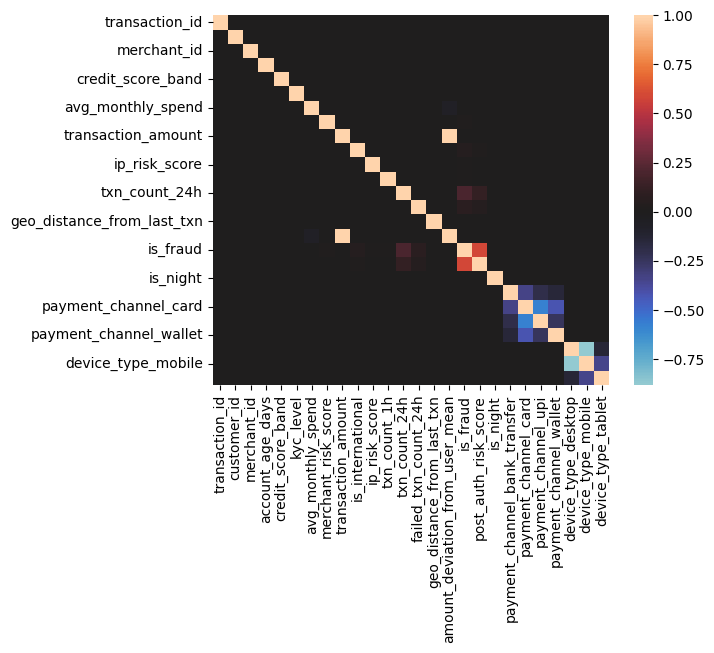

In [4]:
#блок с тепловой картой 

numeric_cols = df_transformed.select_dtypes(include=['int64', 'float64', 'bool']).columns.to_list()

print(numeric_cols)

sns.heatmap(df_transformed[numeric_cols].corr(), center=0)

In [5]:
#Блок с обучением модели

# Признаки (X) и целевая переменная (y)

X = df_transformed.drop(['is_fraud', 'post_auth_risk_score', 'transaction_time'], axis=1)
y = df_transformed['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=6769
)

X_test.info()

<class 'pandas.DataFrame'>
Index: 60023 entries, 193522 to 231547
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   transaction_id                   60023 non-null  int64  
 1   customer_id                      60023 non-null  int64  
 2   merchant_id                      60023 non-null  int64  
 3   account_age_days                 60023 non-null  int64  
 4   credit_score_band                60023 non-null  int64  
 5   kyc_level                        60023 non-null  int64  
 6   avg_monthly_spend                60023 non-null  float64
 7   merchant_risk_score              60023 non-null  float64
 8   transaction_amount               60023 non-null  float64
 9   is_international                 60023 non-null  int64  
 10  ip_risk_score                    60023 non-null  float64
 11  txn_count_1h                     60023 non-null  int64  
 12  txn_count_24h               

In [6]:
model = GaussianNB()
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [7]:
y_pred = model.predict(X_test)

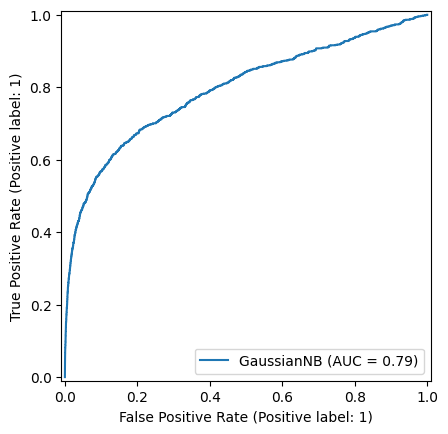

Accuracy: 0.9843726571480932
Precision: 0.9689895281407975
Recall: 0.9843726571480932
F1-score: 0.9766205199918576


In [8]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, average='weighted', zero_division=0))

In [9]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[59085     0]
 [  938     0]]


Итого модель всегда предсказывает, что это не мошенническая операция, так как классы сильно несбалансированы, мошеннических операций сильно меньше обычных, а алгоритм максимизирует вероятность. То есть если один класс (в нашем случае is_fraud=0) встречается намного чаще, модель начинает всегда выбирать его, потому что это минимизирует ошибку.

Попробуем решить эту проблему используя **SMOTE** из imblearn. SMOTE создаёт новые синтетические объекты редкого класса, не копируя их, а генерируя новые между соседними объектами.

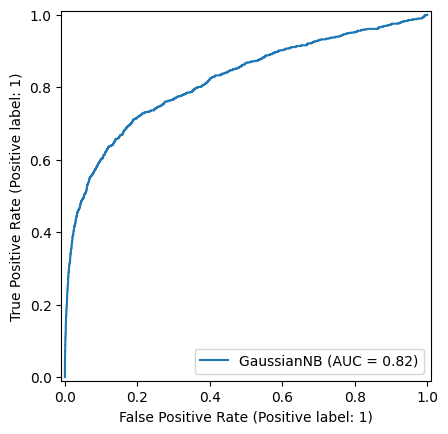

Accuracy: 0.556170134781667
Precision: 0.9745218259793048
Recall: 0.556170134781667
F1-score: 0.6999893346459655
[[32733 26316]
 [  324   650]]


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=6769, stratify=y
)

# pipeline
pipeline = Pipeline([
    ('smote', SMOTE(random_state=6769)),
    ('model', GaussianNB())
])

# обучение
pipeline.fit(X_train, y_train)

# предсказание
y_pred = pipeline.predict(X_test)

# метрики
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, average='weighted', zero_division=0))
print(confusion_matrix(y_test, y_pred))